# nb_01 — Prepare a DP2 subset to play with

Goal (see `docs/SPEC_V01.md`, rough plan step 1): pick a handful of `diaObject` HATS partitions
that span different sky conditions (galactic vs. extragalactic latitude, sparse vs. dense
cadence), keep only objects with more than 10 `diaSources`, and save that small subset to a
shared location so workshop participants can work with it directly instead of touching the
full ~5 TB collection.

**Environment note (RSP notebook aspect):** this repo's `pyproject.toml` is pinned to Python
3.14 to mirror a local conda env, but the RSP kernel runs Python 3.13.9 with `lsdb`/`hats`
already provided by the stack. We do **not** `pip install .` here — we only need the
`datapaths` package on top of the stack, installed directly:

```bash
pip install --user "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
```

`datapaths` resolves two config files under `configs/`: the committed
`artifacts_registry.yaml`, and a machine-local `roots.local.yaml` (gitignored) that must exist
on whatever machine runs this notebook. On this RSP session it maps:

- `dp2_raw` → `/rubin/lsdb_data/dp2` (the full DP2 collections, read-only)
- `dp2_filtered` → `/deleted-sundays/shrra-ung/dp2` (an already `nDiaSources > 10` filtered
  copy of the full `diaObject` collection, ~300 GB, produced separately — see
  `~/WORK/dp2_diaObj_download.py`)
- `dp2_subset` → `~/share/trieste` (small, shareable subset — this notebook's output)
- `misc` → `~/DATA/DP2` (personal scratch)

If you're running this on a different machine, create your own `configs/roots.local.yaml`
with these four keys pointing at wherever the data actually lives there.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hpgeom
import pyarrow.parquet as pq
from astropy.coordinates import SkyCoord
import astropy.units as u

import lsdb

try:
    from datapaths import Datapaths
except ModuleNotFoundError:
    import sys
    print("datapaths not found — installing it into the user site-packages...")
    !{sys.executable} -m pip install --user --quiet "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
    from datapaths import Datapaths

In [2]:
dp = Datapaths()

for root_name in ["dp2_raw", "dp2_filtered", "dp2_subset", "misc"]:
    print(f"{root_name:12s} -> {dp['root_' + root_name]}")

dp2_raw      -> /rubin/lsdb_data/dp2
dp2_filtered -> /deleted-sundays/shrra-ung/dp2
dp2_subset   -> /home/shrra-ung/share/trieste
misc         -> /home/shrra-ung/DATA/DP2


## 1. Open the raw `diaObject` collection

`lsdb.open_catalog` on a HATS *collection* directory opens its main catalog and wires up the
default margin cache. By default it loads only the columns listed as `hats_cols_default` in
the catalog's properties file — for `dia_object_lc` that's `ra`, `dec`, `tract`,
`diaObjectId`, `nDiaSources`, and the two nested light-curve columns `diaSource` and
`diaObjectForcedSource` (each a struct-of-lists, one entry per epoch).

There are also ~190 flat per-band summary columns on disk (`u_psfFluxMean`,
`g_scienceFluxMean`, min/max, etc.) that are *not* loaded unless requested via
`columns=[...]` — worth remembering for nb_02's histogram work, since those summary stats
might be more informative than raw diff fluxes for some of the questions there.

In [3]:
dia_object_cat = lsdb.open_catalog(dp["dp2_raw"] / "dia_object_collection")

print(type(dia_object_cat))
print("npartitions:", dia_object_cat.npartitions)
print("default columns:", list(dia_object_cat.columns))

<class 'lsdb.catalog.catalog.Catalog'>
npartitions: 8393
default columns: ['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract', 'diaObjectForcedSource', 'diaSource']


## 2. Survey partitions without reading any object data

Each HATS partition is one healpix pixel, and a parquet dataset keeps per-row-group statistics
in its `_metadata` footer file: row counts, and per-column min/max. Reading that footer costs
milliseconds and tells us, for all 8393 partitions, both the object count and the
**max `nDiaSources` in the partition** — no need to touch the 232M-row data files themselves.

The max-`nDiaSources` column matters: it's the cheapest available proxy for "does this
partition have any well-observed (high-cadence) objects at all", which turns out to matter a
lot once we filter on `nDiaSources > 10` (see the note in section 3). We also compute each
pixel's galactic latitude from its center coordinates, to see where the low/high-latitude
regions are.

In [4]:
metadata_path = str(
    dp["dp2_raw"] / "dia_object_collection" / "dia_object_lc" / "dataset" / "_metadata"
)
footer = pq.ParquetFile(metadata_path).metadata
ndia_col_idx = footer.schema.names.index("nDiaSources")

rows = []
for i in range(footer.num_row_groups):
    row_group = footer.row_group(i)
    file_path = row_group.column(0).file_path  # e.g. "Norder=7/Dir=100000/Npix=109043.parquet"
    order, pixel = re.search(r"Norder=(\d+)/Dir=\d+/Npix=(\d+)", file_path).groups()
    max_ndia = row_group.column(ndia_col_idx).statistics.max
    rows.append((int(order), int(pixel), row_group.num_rows, max_ndia))

partitions = pd.DataFrame(rows, columns=["order", "pixel", "n_objects", "max_ndia"])
print(f"{len(partitions)} partitions, {partitions['n_objects'].sum():,} objects total")
print((partitions["max_ndia"] <= 10).sum(), "partitions have max(nDiaSources) <= 10")
partitions.head()

8393 partitions, 232,004,216 objects total
110 partitions have max(nDiaSources) <= 10


,order,pixel,n_objects,max_ndia
0,4,1059,2332,13
1,3,265,42199,18
2,7,68159,521,8
3,4,1065,54910,25
4,4,1066,109295,32


In [5]:
nside = 2 ** partitions["order"].to_numpy()
ra, dec = hpgeom.pixel_to_angle(nside, partitions["pixel"].to_numpy(), nest=True, lonlat=True)
galactic = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs").galactic

partitions["ra"] = ra
partitions["dec"] = dec
partitions["gal_b"] = galactic.b.deg

print("galactic latitude range: %.1f to %.1f deg" % (partitions["gal_b"].min(), partitions["gal_b"].max()))
partitions[["order", "pixel", "n_objects", "gal_b"]].describe()

galactic latitude range: -78.4 to 73.2 deg


,order,pixel,n_objects,gal_b
count,8393.000000,8.393000e+03,8393.000000,8393.000000
mean,7.753366,2.421844e+06,27642.585011,3.151920
std,1.509008,4.032643e+06,29750.814255,24.133890
min,2.000000,6.800000e+01,1.000000,-78.367919
25%,7.000000,1.157740e+05,5399.000000,-8.957089
50%,8.000000,4.434540e+05,16500.000000,5.597500
75%,9.000000,2.730908e+06,43597.000000,16.794230
max,11.000000,5.031538e+07,296989.000000,73.156237


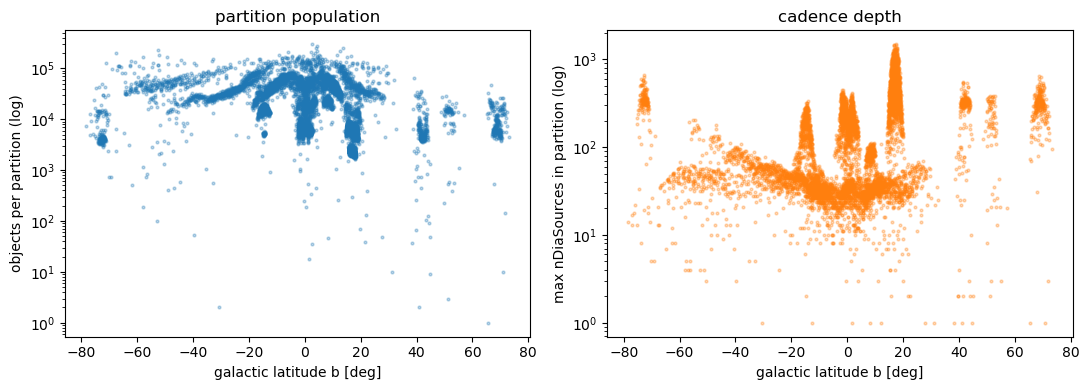

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(partitions["gal_b"], partitions["n_objects"], s=4, alpha=0.3)
axes[0].set_yscale("log")
axes[0].set_xlabel("galactic latitude b [deg]")
axes[0].set_ylabel("objects per partition (log)")
axes[0].set_title("partition population")

axes[1].scatter(partitions["gal_b"], partitions["max_ndia"], s=4, alpha=0.3, color="C1")
axes[1].set_yscale("log")
axes[1].set_xlabel("galactic latitude b [deg]")
axes[1].set_ylabel("max nDiaSources in partition (log)")
axes[1].set_title("cadence depth")

fig.tight_layout()

## 3. Select 4 partitions

Following the spec: one low- and one high-galactic-latitude region, each with a
high-cadence and a low-cadence partition, to get variety in crowding (galactic vs.
extragalactic sources) and in how densely each field was sampled in time.

**First attempt, and why it was wrong:** the natural first idea is to pick the
sparsest/densest partitions by *object count* (`n_objects`). That turned out to be a bad
proxy for cadence — of the 8393 partitions, 110 have `max(nDiaSources) <= 10`, and picking a
"low density" partition by object count landed on two of those: after filtering to
`nDiaSources > 10` (the whole point of this subset), **both partitions were completely
empty**. Sparse partitions in DP2 tend to come from shallow, once-swept sky rather than from
occasionally-visited-but-still-well-sampled objects — object count and cadence depth are
close to independent.

The fix: use `max(nDiaSources)` per partition (from the same free `_metadata` scan) as the
cadence axis instead, and require a minimum object count just to avoid picking a
near-empty partition outright. This is still a coarse proxy — `max` only tells us whether
*some* object in the partition is well sampled, not the typical object — but it's free and it
is the one thing that directly determines whether any object survives the `> 10` filter at
all.

| label | order | pixel | b [deg] | ra, dec | n_objects | max nDiaSources | n after filter | file size |
|---|---|---|---|---|---|---|---|---|
| low_b_high_cad | 7 | 115670 | -0.7 | 271.8, -22.0 | 32,492 | 255 | 3,834 | 241.2 MB |
| low_b_low_cad | 7 | 116608 | -3.7 | 278.4, -16.6 | 37,872 | 16 | 179 | 60.9 MB |
| high_b_high_cad | 7 | 141549 | -72.6 | 8.5, -44.2 | 13,682 | 667 | 848 | 347.7 MB |
| high_b_low_cad | 7 | 141516 | -70.6 | 8.1, -46.2 | 2,370 | 76 | 153 | 10.2 MB |

Total raw size ≈ 660 MB, ~5,000 objects survive the filter — well under the ~4 GB budget,
with room to add more fields later. **This is a starting point, not a fixed choice** — the
code cell below has the thresholds at the top; rerun it with different values to swap in
other fields.

In [7]:
ORDER = 7
LOW_B_MAX = 15.0
HIGH_B_MIN = 55.0
MIN_OBJECTS = 500  # avoid near-empty partitions
MIN_CADENCE, MAX_CADENCE = 15, 800  # bound on max(nDiaSources), avoid extreme outliers

candidates = partitions[
    (partitions["order"] == ORDER)
    & (partitions["n_objects"] >= MIN_OBJECTS)
    & partitions["max_ndia"].between(MIN_CADENCE, MAX_CADENCE)
]
low_b = candidates[candidates["gal_b"].abs() < LOW_B_MAX]
high_b = candidates[candidates["gal_b"].abs() > HIGH_B_MIN]


def pick(df, high_cadence):
    return df.loc[df["max_ndia"].idxmax() if high_cadence else df["max_ndia"].idxmin()]


picks = pd.DataFrame([
    pick(low_b, high_cadence=True).rename("low_b_high_cad"),
    pick(low_b, high_cadence=False).rename("low_b_low_cad"),
    pick(high_b, high_cadence=True).rename("high_b_high_cad"),
    pick(high_b, high_cadence=False).rename("high_b_low_cad"),
])
picks.index.name = "label"
picks[["order", "pixel", "n_objects", "max_ndia", "gal_b", "ra", "dec"]]

,order,pixel,n_objects,max_ndia,gal_b,ra,dec
label,,,,,,,
low_b_high_cad,7.0,115670.0,32492.0,255.0,-0.695122,271.757812,-22.024313
low_b_low_cad,7.0,116608.0,37872.0,16.0,-3.719769,278.437500,-16.646040
high_b_high_cad,7.0,141549.0,13682.0,667.0,-72.567431,8.483607,-44.201530
high_b_low_cad,7.0,141516.0,2370.0,76.0,-70.576947,8.076923,-46.178180


## 4. Filter to `nDiaSources > 10` and write the subset

`pixel_search` restricts the catalog to just these 4 partitions before anything is read from
disk, so the `query` + `compute`/`write_catalog` below only ever touch ~660 MB of source
files, not the full collection.

In [8]:
selected_pixels = list(zip(picks["order"].astype(int), picks["pixel"].astype(int)))

subset_cat = dia_object_cat.pixel_search(selected_pixels)
subset_cat = subset_cat.query("nDiaSources > 10")
subset_cat = subset_cat.prune_empty_partitions()  # returns a new catalog, doesn't mutate in place
subset_cat

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/lsdb/catalog/dataset/healpix_dataset.py:1281: RuntimeWarning: Pruning empty partitions is expensive. It may run slow!
  warnings.warn("Pruning empty partitions is expensive. It may run slow!", RuntimeWarning)


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource
npartitions=4,,,,,,,
"Order: 7, Pixel: 115670",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
"Order: 7, Pixel: 116608",...,...,...,...,...,...,...
"Order: 7, Pixel: 141516",...,...,...,...,...,...,...
"Order: 7, Pixel: 141549",...,...,...,...,...,...,...


In [9]:
subset_path = dp["dp2_subset"] / "dia_object_lc_10plus"

subset_cat.write_catalog(
    subset_path,
    overwrite=True,
    create_thumbnail=False,
    progress_bar=False,
)
print("wrote subset catalog to", subset_path)

wrote subset catalog to /home/shrra-ung/share/trieste/dia_object_lc_10plus


### Registering the subset with `datapaths`

`dp.register`/`dp.save` hash and track a single *file*, not a directory tree — a written HATS
collection is a few hundred parquet files plus properties/metadata files. So instead of
registering the whole tree, we register its `collection.properties` file as a named pointer:
this gets it a `name`, a hash (of that one small file — good enough to notice if the subset
was regenerated), tags and notes in the committed registry, and makes it show up in
`dp.list()`/`dp.print_paths()`. To actually **open** the catalog in later notebooks, resolve
the root and append the same relative path used here (`dp["dp2_subset"] / "dia_object_lc_10plus"`),
same as this notebook does — the registry entry is provenance, not the access path.

In [10]:
dp.register(
    name="dia_object_lc_10plus",
    type="dp2_subset",
    fmt="hats-collection",
    src_path=str(subset_path / "collection.properties"),
    tags=["nb01", "dp2", "diaObject"],
    notes=(
        "4 diaObject partitions (order 7), nDiaSources > 10: 2 low/high galactic "
        "latitude x 2 low/high cadence (max nDiaSources), see nb_01 section 3."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_10plus")

name                 | path                                                                     | tags               | type       | updated at               
---------------------+--------------------------------------------------------------------------+--------------------+------------+--------------------------
dia_object_lc_10plus | /home/shrra-ung/share/trieste/dia_object_lc_10plus/collection.properties | diaobject,dp2,nb01 | dp2_subset | 2026-08-27T16:10:23+00:00


## 5. Read the subset back, convert to pandas/numpy

Re-opening the written subset exercises the same `datapaths` + `lsdb` path everyone else will
use. `.compute()` turns the (small, 4-partition) lazy `lsdb.Catalog` into an in-memory
`nested_pandas.NestedFrame` — a pandas `DataFrame` subclass where the nested light-curve
columns hold one array/list per row. Dropping those nested columns gives an ordinary flat
`pandas.DataFrame`; pulling a single column out gives a plain `numpy` array as usual.

In [11]:
reopened = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus")
nested_df = reopened.compute()
print(type(nested_df), nested_df.shape)

flat_df = nested_df.drop(columns=["diaSource", "diaObjectForcedSource"])
print(type(flat_df), flat_df.shape)
flat_df.head()

Computing Catalog:   0%|          | 0/4 [00:00<?, ?it/s]

<class 'nested_pandas.nestedframe.core.NestedFrame'> (5014, 7)
<class 'nested_pandas.nestedframe.core.NestedFrame'> (5014, 5)


,dec,diaObjectId,nDiaSources,ra,tract
_healpix_29,,,,,
2034888161534904515,-22.341336,760838269482044508,36,271.758743,5858
2034888161540601442,-22.341621,760838269482041650,35,271.758361,5858
2034888162016290001,-22.342857,760838269482044921,40,271.755149,5858
2034888163488046568,-22.338403,760838269482041645,53,271.759042,5858
2034888163501648456,-22.338239,760838269482046521,19,271.759059,5858


In [12]:
n_dia_sources = flat_df["nDiaSources"].to_numpy()
print(type(n_dia_sources), n_dia_sources.dtype, n_dia_sources.shape)
print("min/median/max:", n_dia_sources.min(), np.median(n_dia_sources), n_dia_sources.max())

<class 'numpy.ndarray'> int64 (5014,)
min/median/max: 11 21.0 667


## 6. Building a long-format light-curve table via `explode`

Each row of `nested_df` is one object with a nested `diaSource` column holding its whole
light curve as arrays. `nested_pandas`'s `.explode(column)` turns that into a long-format
table with one row per epoch — the shape most people expect for plotting or period-finding.

Two things to watch for:
- `diaSource` itself has `ra`/`dec` columns that collide with the object-level `ra`/`dec`,
  so select only `diaObjectId` + the nested column (plus whatever flat columns you actually
  need) before exploding.
- `explode` works on an already-`compute()`d, pandas-backed frame — it's a `nested_pandas`
  method, not something you call on the lazy `lsdb.Catalog` directly.

In [13]:
example_ids = nested_df["diaObjectId"].iloc[:3]
lc_table = nested_df.loc[
    nested_df["diaObjectId"].isin(example_ids), ["diaObjectId", "diaSource"]
].explode("diaSource")

print(lc_table.shape)
lc_table[["diaObjectId", "band", "midpointMjdTai", "psfMag", "psfMagErr"]].head(10)

(111, 51)


,diaObjectId,band,midpointMjdTai,psfMag,psfMagErr
_healpix_29,,,,,
2034888161534904515,760838269482044508,u,60797.250678,<NA>,<NA>
2034888161534904515,760838269482044508,g,60797.281718,<NA>,<NA>
2034888161534904515,760838269482044508,g,60797.287193,<NA>,<NA>
2034888161534904515,760838269482044508,g,60797.298405,23.501162,0.183709
2034888161534904515,760838269482044508,g,60797.302492,<NA>,<NA>
2034888161534904515,760838269482044508,r,60798.197877,23.335041,0.22492
2034888161534904515,760838269482044508,g,60798.280263,<NA>,<NA>
2034888161534904515,760838269482044508,g,60798.280748,<NA>,<NA>
2034888161534904515,760838269482044508,g,60798.284235,<NA>,<NA>


## Next

The subset now lives at `dp["dp2_subset"] / "dia_object_lc_10plus"` (registered as
`dia_object_lc_10plus` in `configs/artifacts_registry.yaml`) and covers ~5,000 objects across
4 partitions chosen for latitude/cadence variety. nb_02 picks up from here to build the
per-object and per-LC statistics histograms (durations, amplitudes, cadence gaps) called for
in the spec.

Open questions carried forward, not resolved here:
- Whether 4 partitions is enough variety, or whether the workshop wants more fields once
  people start looking at actual light curves.
- The margin cache (`dia_object_lc_10plus_5arcs`) was written automatically alongside the
  main catalog, inherited from the source collection's `default_margin` — untested so far
  since this project's non-goals exclude crossmatching for now.